## Forecasting On Air Passenger data

# Project Pipeline
Load Data
   ↓
Clean & Handle Missing Values
   ↓
Convert Date Index
   ↓
Visualization
   ↓
Stationarity Check
   ↓
Differencing
   ↓
Train/Test Split
   ↓
Model Training (ARIMA)
   ↓
Forecast
   ↓
Evaluation
   ↓
Future Prediction

In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load AirPassengers Dataset

In [108]:
df=pd.read_csv(r'C:\Users\anupa\Desktop\Python Learning\Forecasting\AirPassengers.csv')

In [109]:
df.head()

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [110]:
df.tail()

,Month,Passengers
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390
143,1960-12,432


In [111]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Month       144 non-null    object
 1   Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


# Convert Month Column

In [112]:
df['Month'] = pd.to_datetime(df['Month'])

In [113]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Month       144 non-null    datetime64[ns]
 1   Passengers  144 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.4 KB


In [114]:
df.set_index('Month', inplace=True)

# Check Missing Values

In [115]:
df.isnull().sum()

Passengers    0
dtype: int64

In [116]:
df = df.dropna()

# Visualize Time Series

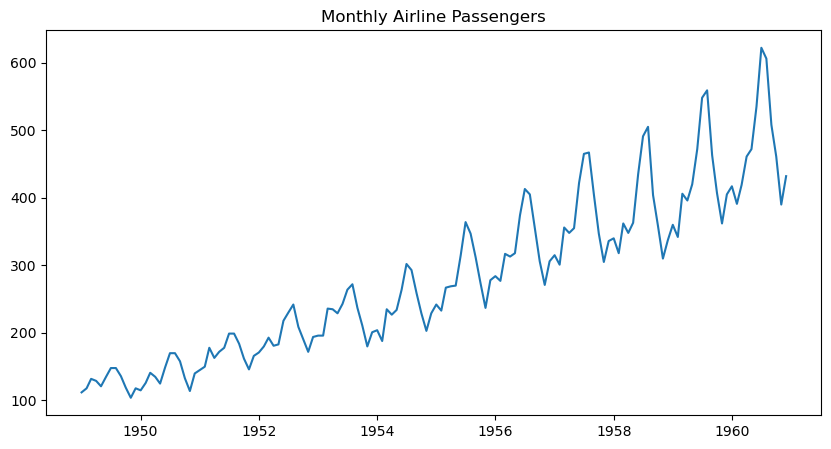

In [117]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df)
plt.title("Monthly Airline Passengers")
plt.show()

# Check Stationarity

In [118]:
result = adfuller(df['Passengers'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: 0.8153688792060511
p-value: 0.991880243437641


Interpretation:

p < 0.05 → Stationary

p > 0.05 → Need differencing

# Difference the Series

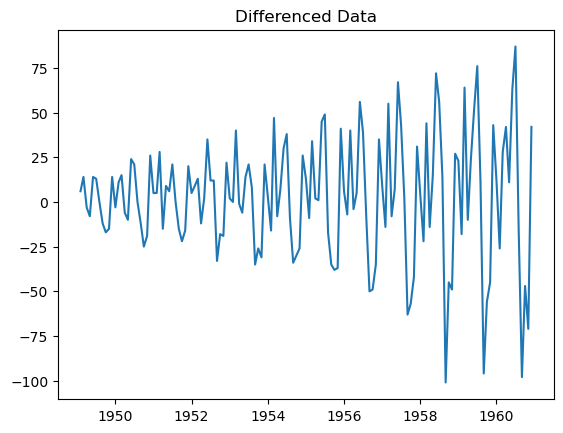

In [119]:
df_diff = df.diff().dropna()

plt.plot(df_diff)
plt.title("Differenced Data")
plt.show()

# Second Stationarity Checking

In [120]:
result = adfuller(df_diff['Passengers'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -2.8292668241699874
p-value: 0.05421329028382711


In [121]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ACF PLot

<Figure size 1000x500 with 0 Axes>

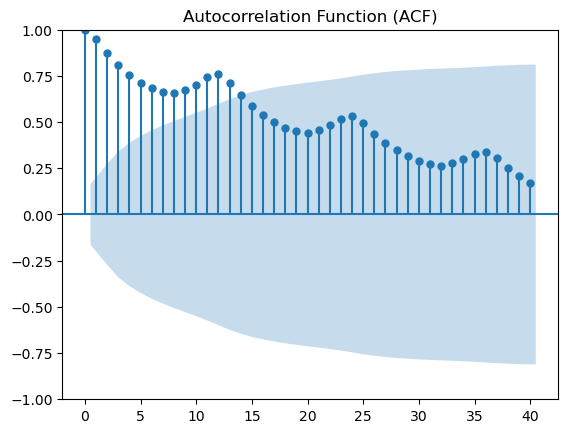

In [122]:
plt.figure(figsize=(10,5))

plot_acf(df['Passengers'], lags=40)

plt.title("Autocorrelation Function (ACF)")
plt.show()

# Pacf Plat

<Figure size 1000x500 with 0 Axes>

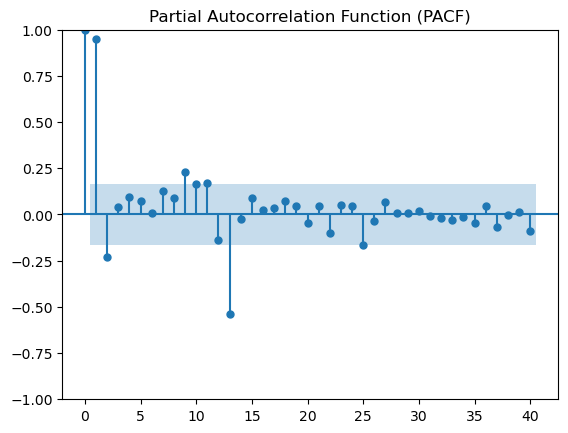

In [123]:
plt.figure(figsize=(10,5))

plot_pacf(df['Passengers'], lags=40)

plt.title("Partial Autocorrelation Function (PACF)")
plt.show()

# Train Test Split

In [124]:
train_size = int(len(df) * 0.8)

train = df[:train_size]
test = df[train_size:]

In [125]:
import warnings
warnings.filterwarnings("ignore")

# Build ARIMA Model

In [126]:
model = ARIMA(train['Passengers'], order=(4,1,12))
model_fit = model.fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                  115
Model:                ARIMA(4, 1, 12)   Log Likelihood                -476.574
Date:                Thu, 12 Mar 2026   AIC                            987.148
Time:                        11:49:58   BIC                           1033.664
Sample:                    01-01-1949   HQIC                          1006.026
                         - 07-01-1958                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.6633      0.070     23.864      0.000       1.527       1.800
ar.L2         -1.8088      0.127    -14.231      0.000      -2.058      -1.560
ar.L3          1.5601      0.127     12.307      0.0

# Forecast

In [127]:
forecast = model_fit.forecast(steps=len(test))
forecast = pd.Series(forecast, index=test.index)
forecast 

Month
1958-08-01    470.543158
1958-09-01    421.028322
1958-10-01    387.025526
1958-11-01    354.167550
1958-12-01    344.483601
1959-01-01    315.376145
1959-02-01    304.999112
1959-03-01    341.036868
1959-04-01    357.994043
1959-05-01    372.194188
1959-06-01    415.348540
1959-07-01    455.073694
1959-08-01    449.531771
1959-09-01    422.625184
1959-10-01    409.883699
1959-11-01    391.905139
1959-12-01    348.207297
1960-01-01    313.098103
1960-02-01    317.500037
1960-03-01    336.814279
1960-04-01    346.694255
1960-05-01    367.590790
1960-06-01    410.529709
1960-07-01    441.669344
1960-08-01    439.241252
1960-09-01    426.502512
1960-10-01    418.499676
1960-11-01    395.589064
1960-12-01    354.334062
Name: predicted_mean, dtype: float64

# Visualization of Forecast

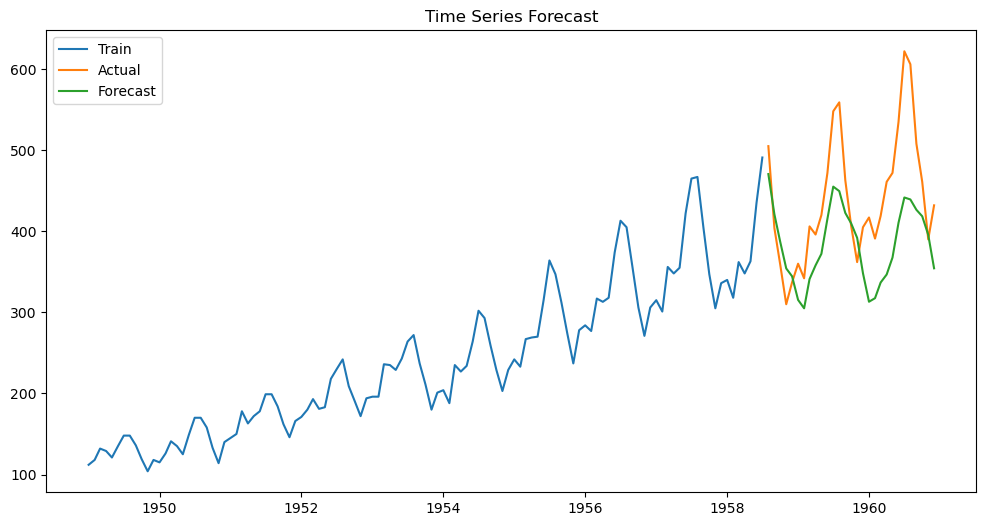

In [128]:
plt.figure(figsize=(12,6))

plt.plot(train, label="Train")
plt.plot(test, label="Actual")
plt.plot(forecast, label="Forecast")

plt.legend()
plt.title("Time Series Forecast")
plt.show()

# Evaluate Model

In [129]:
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
from sklearn.metrics import mean_absolute_percentage_error
forecast = model_fit.predict(start=len(train), end=len(df)-1)
y_true = test['Passengers']
y_pred = forecast
mape = mean_absolute_percentage_error(y_true, y_pred)
print("MAPE:", mape*100)
print("MAE:", mae)
print("RMSE:", rmse)

MAPE: 14.153692801273564
MAE: 65.85099595444427
RMSE: 79.31109973905562


# Future Forecast

Forecast next 30 days.

In [130]:
future = model_fit.forecast(steps=30)

print(future)

1958-08-01    470.543158
1958-09-01    421.028322
1958-10-01    387.025526
1958-11-01    354.167550
1958-12-01    344.483601
1959-01-01    315.376145
1959-02-01    304.999112
1959-03-01    341.036868
1959-04-01    357.994043
1959-05-01    372.194188
1959-06-01    415.348540
1959-07-01    455.073694
1959-08-01    449.531771
1959-09-01    422.625184
1959-10-01    409.883699
1959-11-01    391.905139
1959-12-01    348.207297
1960-01-01    313.098103
1960-02-01    317.500037
1960-03-01    336.814279
1960-04-01    346.694255
1960-05-01    367.590790
1960-06-01    410.529709
1960-07-01    441.669344
1960-08-01    439.241252
1960-09-01    426.502512
1960-10-01    418.499676
1960-11-01    395.589064
1960-12-01    354.334062
1961-01-01    326.474064
Freq: MS, Name: predicted_mean, dtype: float64


# Plot future prediction:

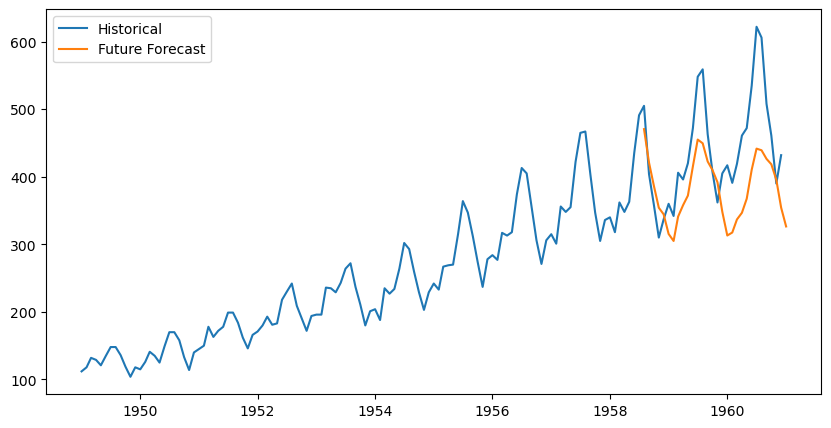

In [131]:
plt.figure(figsize=(10,5))
plt.plot(df, label="Historical")
plt.plot(future, label="Future Forecast")
plt.legend()
plt.show()

## Forecasting On WALLMART data

# Project Workflow
1 Data Collection (Walmart Dataset)
        ↓
2 Data Cleaning & Preprocessing
        ↓
3 Exploratory Data Analysis
        ↓
4 Feature Aggregation
        ↓
5 Train/Test Split
        ↓
6 ARIMA Model Training
        ↓
7 Forecasting
        ↓
8 Model Evaluation
        ↓
9 Future Sales Prediction

# Load Dataset

In [132]:
df_1=pd.read_csv(r'C:\Users\anupa\Desktop\Python Learning\Forecasting\train.csv')

In [133]:
df_1.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


# Data Preprocessing
Convert Date column to datetime.

In [134]:
df_1['Date'] = pd.to_datetime(df_1['Date'])

In [135]:
df_1 =df_1.sort_values('Date')

# Aggregate Weekly Sales

In [136]:
sales = df_1.groupby('Date')['Weekly_Sales'].sum().reset_index()
sales.head()

,Date,Weekly_Sales
0,2010-02-05,49750740.50
1,2010-02-12,48336677.63
2,2010-02-19,48276993.78
3,2010-02-26,43968571.13
4,2010-03-05,46871470.30


In [137]:
sales.set_index('Date', inplace=True)

# Exploratory Data Analysis

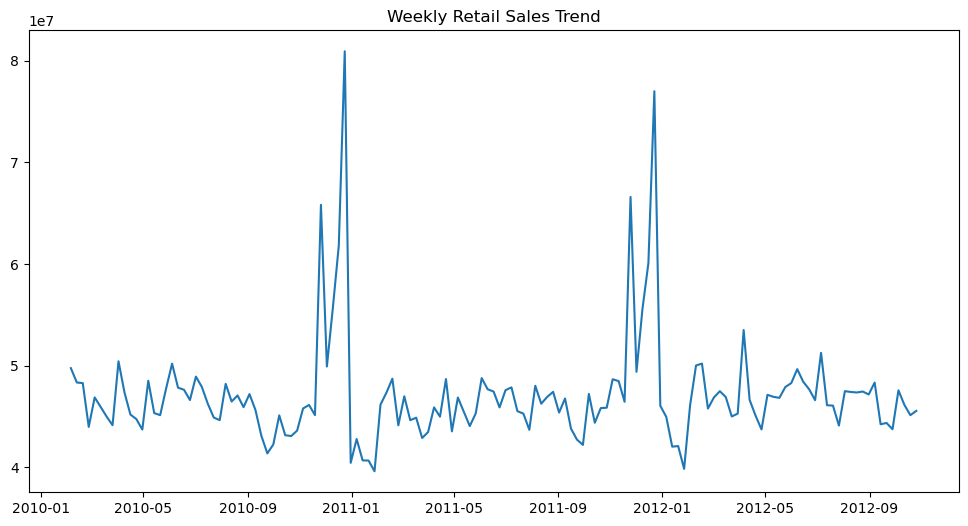

In [138]:
plt.figure(figsize=(12,6))
plt.plot(sales)
plt.title("Weekly Retail Sales Trend")
plt.show()

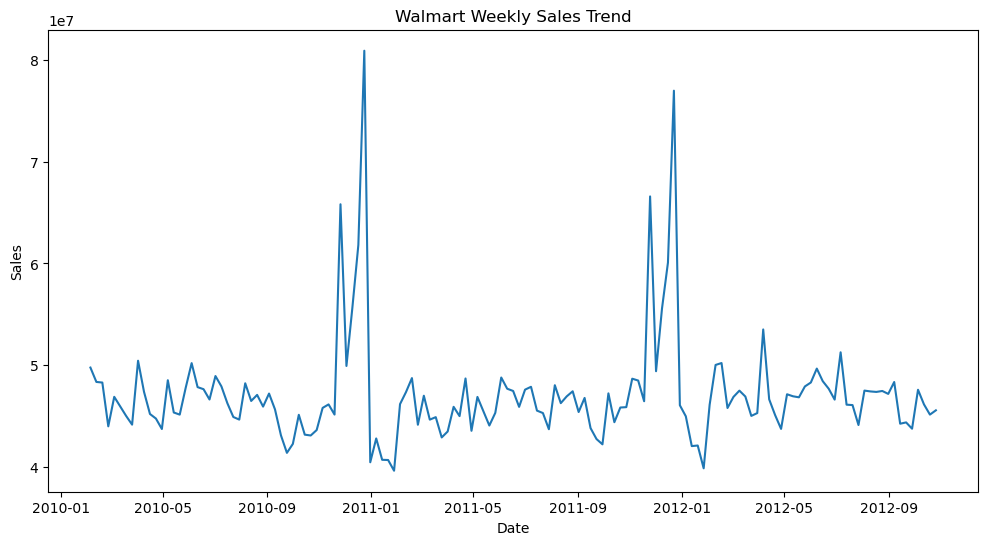

In [139]:
plt.figure(figsize=(12,6))
plt.plot(sales)
plt.title("Walmart Weekly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

# Check Stationarity

In [140]:
result = adfuller(sales['Weekly_Sales'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -5.908297957186333
p-value: 2.675979158986027e-07


# Difference the series

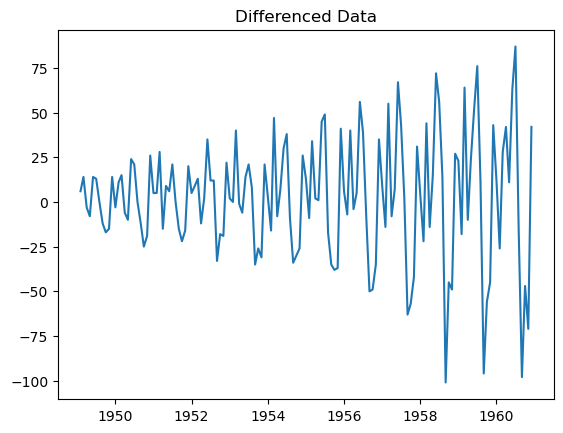

In [141]:

sales_diff =  sales.diff().dropna()

plt.plot(df_diff)
plt.title("Differenced Data")
plt.show()

# Second Stationarity Checking

In [142]:
result = adfuller(sales_diff['Weekly_Sales'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -6.699469309617219
p-value: 3.922578707076774e-09


# Train Test Split

In [143]:
train_size = int(len(sales)*0.8)
train = sales[:train_size]
test = sales[train_size:]


# ACF Plot

<Figure size 1000x500 with 0 Axes>

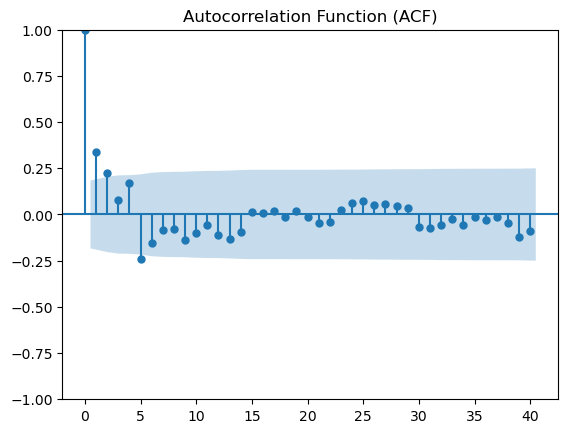

In [144]:
plt.figure(figsize=(10,5))

plot_acf(train['Weekly_Sales'], lags=40)

plt.title("Autocorrelation Function (ACF)")
plt.show()

# PACF Plot

<Figure size 1000x500 with 0 Axes>

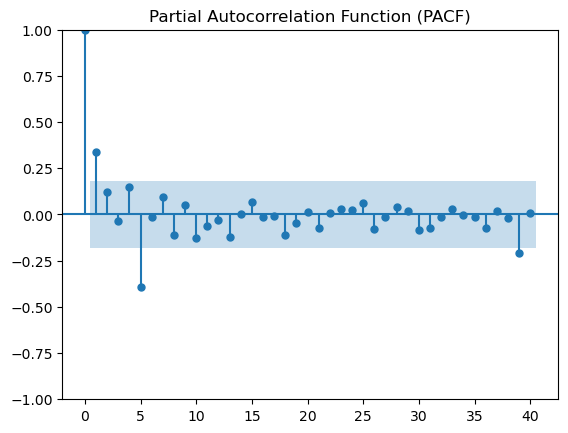

In [145]:
plt.figure(figsize=(10,5))

plot_pacf(train['Weekly_Sales'], lags=40)

plt.title("Partial Autocorrelation Function (PACF)")
plt.show()

# Build ARIMA Model

In [146]:
model = ARIMA(train['Weekly_Sales'], order=(3,0,2))
model_fit = model.fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:           Weekly_Sales   No. Observations:                  114
Model:                 ARIMA(3, 0, 2)   Log Likelihood               -1929.169
Date:                Thu, 12 Mar 2026   AIC                           3872.339
Time:                        11:50:00   BIC                           3891.492
Sample:                    02-05-2010   HQIC                          3880.112
                         - 04-06-2012                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       4.722e+07   3.13e+05    150.998      0.000    4.66e+07    4.78e+07
ar.L1          0.5719      0.269      2.127      0.033       0.045       1.099
ar.L2          0.7401      0.302      2.447      0.0

# Forecast Test Data

In [147]:
forecast = model_fit.forecast(steps=len(test))
forecast = pd.Series(forecast, index=test.index)
print("Test length:", len(test))
print("Forecast length:", len(forecast))

Test length: 29
Forecast length: 29


# Visualization

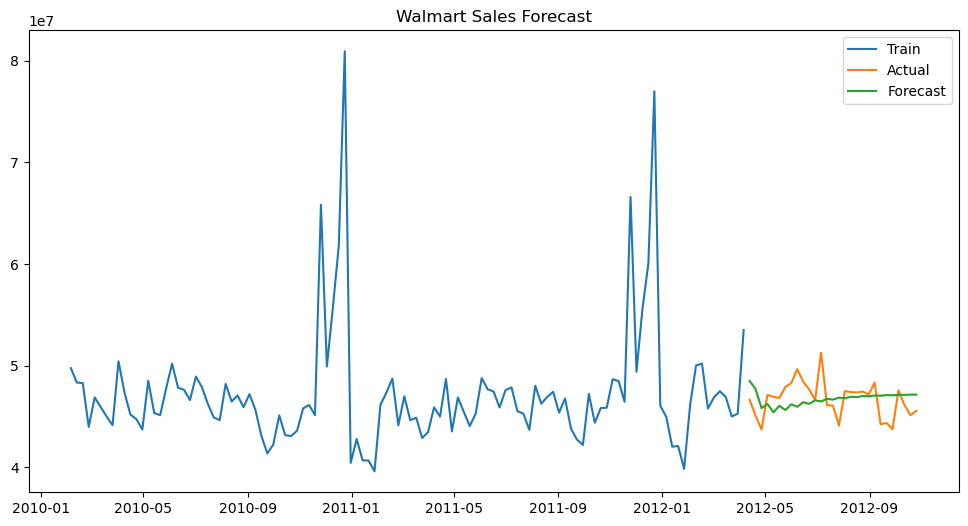

In [148]:
plt.figure(figsize=(12,6))

plt.plot(train, label="Train")
plt.plot(test, label="Actual")
plt.plot(forecast, label="Forecast")

plt.legend()
plt.title("Walmart Sales Forecast")
plt.show()

# Model Evaluation

In [149]:
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
from sklearn.metrics import mean_absolute_percentage_error
y_true = test['Weekly_Sales']
y_pred = forecast
mape = mean_absolute_percentage_error(y_true, y_pred)
print("MAPE:", mape*100)
print("MAE:", mae)
print("RMSE:", rmse)

MAPE: 3.5177125714183943
MAE: 1639350.6633726766
RMSE: 2002320.0753415893


# Forecast Future Sales

In [150]:
future = model_fit.forecast(steps=12)

print(future)

2012-04-13    4.850096e+07
2012-04-20    4.769389e+07
2012-04-27    4.580910e+07
2012-05-04    4.622761e+07
2012-05-11    4.540987e+07
2012-05-18    4.604098e+07
2012-05-25    4.562149e+07
2012-06-01    4.619100e+07
2012-06-08    4.594202e+07
2012-06-15    4.639675e+07
2012-06-22    4.623411e+07
2012-06-29    4.658187e+07
Freq: W-FRI, Name: predicted_mean, dtype: float64


# Plot:

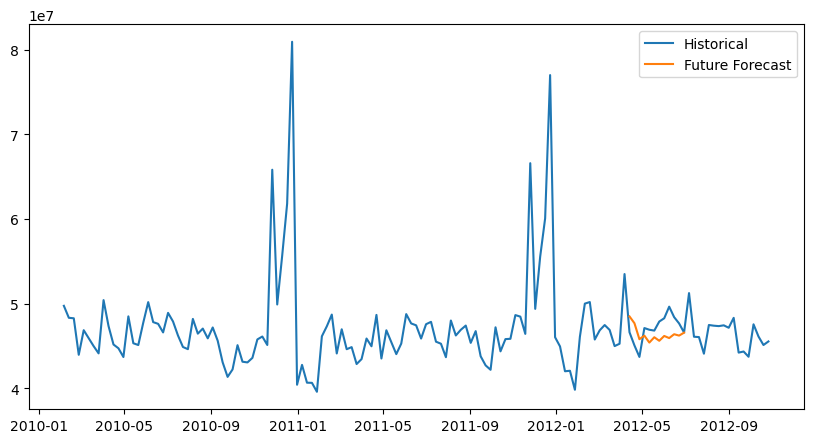

In [151]:
plt.figure(figsize=(10,5))
plt.plot(sales, label="Historical")
plt.plot(future, label="Future Forecast")
plt.legend()
plt.show()

# Forecasting using SARIMA

In [152]:
#pip install pmdarima

# Rolling mean visualization:

<Axes: xlabel='Date'>

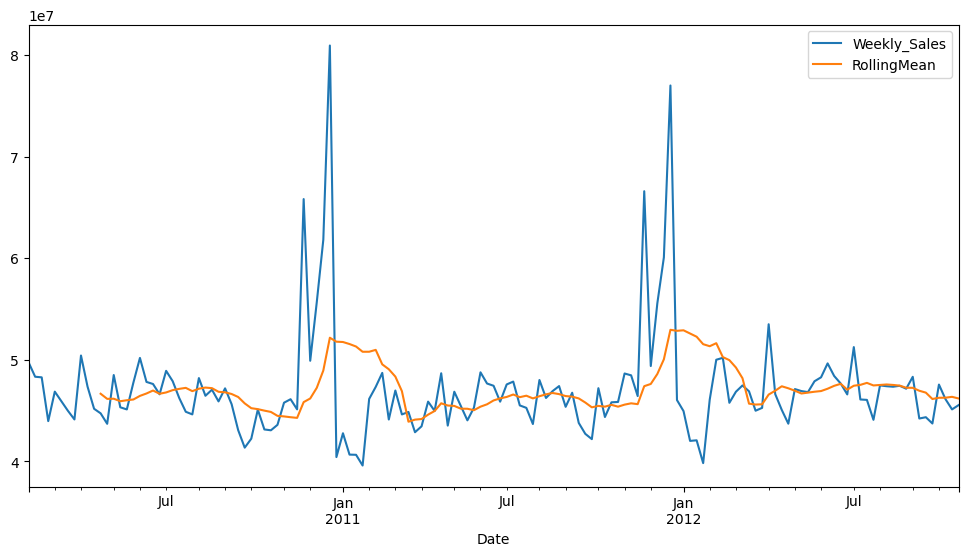

In [153]:
sales['RollingMean'] = sales['Weekly_Sales'].rolling(window=12).mean()

sales[['Weekly_Sales','RollingMean']].plot(figsize=(12,6))

# Feature Engineering (Lag Features)

In [154]:
sales['lag_1'] = sales['Weekly_Sales'].shift(1)
sales['lag_2'] = sales['Weekly_Sales'].shift(2)
sales['lag_3'] = sales['Weekly_Sales'].shift(3)

sales.dropna(inplace=True)

# auto_arima

In [155]:
from pmdarima import auto_arima

model = auto_arima(train,
                   seasonal=True,
                   m=12,
                   trace=True)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=inf, Time=0.80 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=3886.296, Time=0.02 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=3876.060, Time=0.15 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=3879.935, Time=0.05 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=4356.183, Time=0.02 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=3874.374, Time=0.02 sec
 ARIMA(1,0,0)(0,0,1)[12] intercept   : AIC=3875.883, Time=0.07 sec
 ARIMA(1,0,0)(1,0,1)[12] intercept   : AIC=inf, Time=0.39 sec
 ARIMA(2,0,0)(0,0,0)[12] intercept   : AIC=3874.676, Time=0.03 sec
 ARIMA(1,0,1)(0,0,0)[12] intercept   : AIC=3875.641, Time=0.03 sec
 ARIMA(0,0,1)(0,0,0)[12] intercept   : AIC=3878.647, Time=0.03 sec
 ARIMA(2,0,1)(0,0,0)[12] intercept   : AIC=3876.670, Time=0.06 sec
 ARIMA(1,0,0)(0,0,0)[12]             : AIC=inf, Time=0.02 sec

Best model:  ARIMA(1,0,0)(0,0,0)[12] intercept
Total fit time: 1.711 seconds


# SARIMAX

In [156]:

from statsmodels.tsa.statespace.sarimax import SARIMAX
model = SARIMAX(train['Weekly_Sales'],
                order=(3,0,2),
                seasonal_order=(0,0,0,12))

result = model.fit()

forecast = result.forecast(steps=len(test))

# FORECAST

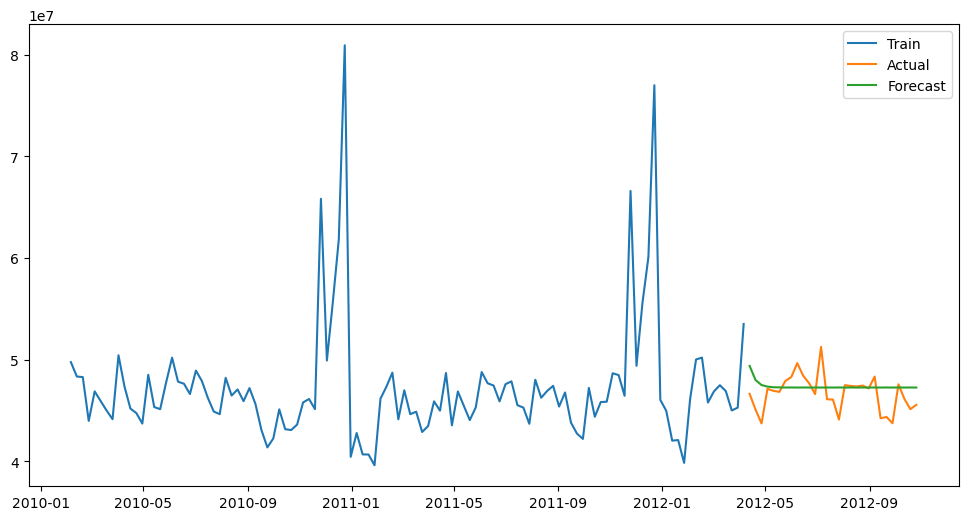

In [157]:
plt.figure(figsize=(12,6))

plt.plot(train.index, train['Weekly_Sales'], label='Train')
plt.plot(test.index, test['Weekly_Sales'], label='Actual')
plt.plot(test.index, forecast, label='Forecast')

plt.legend()
plt.show()

# Model Evaluation

In [158]:
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
from sklearn.metrics import mean_absolute_percentage_error
y_true = test['Weekly_Sales']
y_pred = forecast
mape = mean_absolute_percentage_error(y_true, y_pred)
print("MAPE:", mape*100)
print("MAE:", mae)
print("RMSE:", rmse)

MAPE: 3.207319794036257
MAE: 1476309.333447166
RMSE: 1935415.750511746


# Forecast Future Sales

In [159]:
future_sales = model_fit.forecast(steps=12)

print(future)

2012-04-13    4.850096e+07
2012-04-20    4.769389e+07
2012-04-27    4.580910e+07
2012-05-04    4.622761e+07
2012-05-11    4.540987e+07
2012-05-18    4.604098e+07
2012-05-25    4.562149e+07
2012-06-01    4.619100e+07
2012-06-08    4.594202e+07
2012-06-15    4.639675e+07
2012-06-22    4.623411e+07
2012-06-29    4.658187e+07
Freq: W-FRI, Name: predicted_mean, dtype: float64


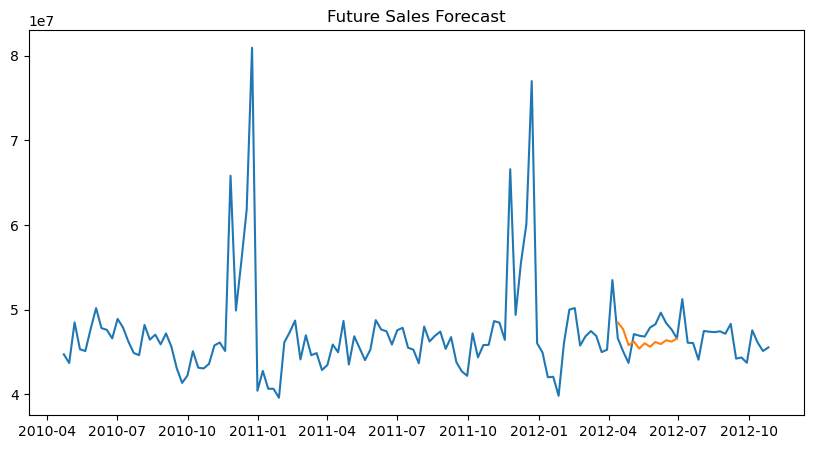

In [160]:
plt.figure(figsize=(10,5))

plt.plot(sales.index, sales['Weekly_Sales'])
plt.plot(future_sales.index, future_sales)

plt.title("Future Sales Forecast")
plt.show()

In [161]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX

#from prophet import Prophet

## SARIMAX modeL WITH exogenous variables

In [165]:
train= pd.read_csv(r'C:\Users\anupa\Desktop\Python Learning\Forecasting\train.csv')
features = pd.read_csv(r"C:\Users\anupa\Desktop\Python Learning\Forecasting\features.csv")
stores = pd.read_csv(r"C:\Users\anupa\Desktop\Python Learning\Forecasting\stores.csv")

# Merge datasets

In [166]:

df = train.merge(features, on=["Store", "Date", "IsHoliday"])
df = df.merge(stores, on="Store")

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
277665,29,5,2010-02-05,15552.08,False,24.36,2.788,NaN,NaN,NaN,NaN,NaN,131.527903,10.064,B,93638
277808,29,6,2010-02-05,3200.22,False,24.36,2.788,NaN,NaN,NaN,NaN,NaN,131.527903,10.064,B,93638
277951,29,7,2010-02-05,10820.05,False,24.36,2.788,NaN,NaN,NaN,NaN,NaN,131.527903,10.064,B,93638
278094,29,8,2010-02-05,20055.64,False,24.36,2.788,NaN,NaN,NaN,NaN,NaN,131.527903,10.064,B,93638


# Aggregate Weekly Sales

In [167]:

#For simplicity we forecast total weekly sales.

sales = df.groupby('Date')['Weekly_Sales'].sum().reset_index()
sales = sales.set_index('Date')

# Add Exogenous Variables

In [168]:

exog = df.groupby('Date')[['Temperature','Fuel_Price','CPI','Unemployment']].mean()

# Train Test Split

In [169]:

train_size = int(len(sales)*0.8)

train_sales = sales[:train_size]
test_sales = sales[train_size:]

train_exog = exog[:train_size]
test_exog = exog[train_size:]

# Build SARIMAX Model

In [170]:

from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(train_sales,
                exog=train_exog,
                order=(3,0,2),
                seasonal_order=(0,0,0,12))

results = model.fit()

print(results.summary())

                               SARIMAX Results                                
Dep. Variable:           Weekly_Sales   No. Observations:                  114
Model:               SARIMAX(3, 0, 2)   Log Likelihood               -1925.916
Date:                Thu, 12 Mar 2026   AIC                           3871.833
Time:                        11:50:57   BIC                           3899.195
Sample:                    02-05-2010   HQIC                          3882.937
                         - 04-06-2012                                         
Covariance Type:                  opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Temperature  -5.796e+04    6.3e+04     -0.919      0.358   -1.82e+05    6.56e+04
Fuel_Price   -1.825e+06    3.5e+05     -5.219      0.000   -2.51e+06   -1.14e+06
CPI           3.266e+05   2.17e+04     15.02

In [171]:
forecast = results.predict(start=len(train_sales),
                           end=len(sales)-1,
                           exog=test_exog)

# Plot Forecast vs Actual

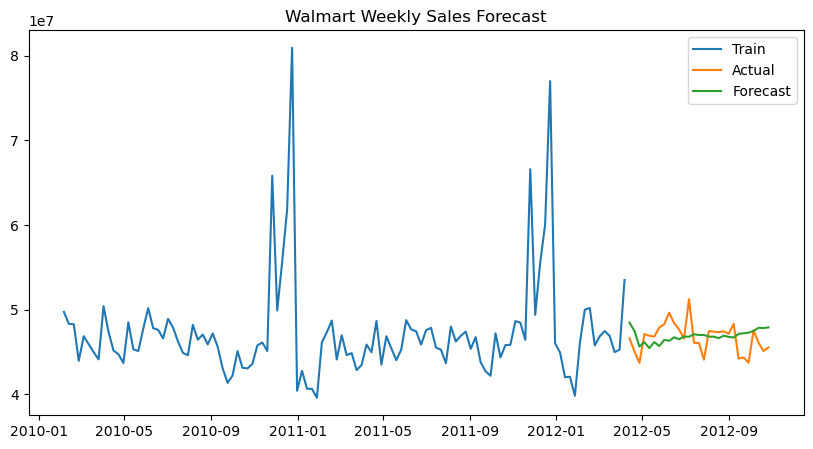

In [172]:

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(train_sales, label="Train")
plt.plot(test_sales, label="Actual")
plt.plot(forecast, label="Forecast")

plt.legend()
plt.title("Walmart Weekly Sales Forecast")
plt.show()

# Evaluate Forecast

In [173]:
mae = mean_absolute_error(test_sales, forecast)
rmse = np.sqrt(mean_squared_error(test_sales, forecast))
from sklearn.metrics import mean_absolute_percentage_error
y_true = test_sales['Weekly_Sales']
y_pred = forecast
mape = mean_absolute_percentage_error(y_true, y_pred)
print("MAPE:", mape*100)
print("MAE:", mae)
print("RMSE:", rmse)

MAPE: 3.6908585674640726
MAE: 1715020.5780249063
RMSE: 2033308.2402204357
